# FRM Parte I, libro 2: Análisis cuantitativo

| Caso | Tema del programa |
|---|---|
| 1 | Momentos muestrales y distribución de los retornos |
| 2 | Pruebas de hipótesis e intervalos de confianza |
| 3 | Regresión lineal y diagnóstico de supuestos |
| 4 | Series de tiempo estacionarias y no estacionarias |
| 5 | Medición de la volatilidad: EWMA y GARCH |
| 6 | Correlación variable en el tiempo |
| 7 | Simulación de Monte Carlo y bootstrap |
| 8 | Aprendizaje automático para predecir incumplimientos |

## Configuración

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller

from dsaplicado import datos, frm, portafolio as pf, riesgo as rg
from dsaplicado.graficos import COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje

warnings.filterwarnings("ignore")
aplicar_estilo()
pd.set_option("display.float_format", "{:.4f}".format)
RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "05_FRM" / "figuras"

precios = datos.cargar_precios(RAIZ / "datos" / "precios_ipsa.csv", {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
                               "2019-01-01", "2026-09-01").ffill()
acciones = list(datos.ACCIONES_IPSA.values())
retornos = pf.retornos_simples(precios).dropna()
cartera = retornos[acciones].mean(axis=1)
log_ipsa = np.log(precios["ETF IPSA"]).diff().dropna()
dolar = datos.cargar_indicador(RAIZ / "datos" / "dolar_historico.csv", "dolar", range(2000, 2027))
log_dolar = np.log(dolar).diff().dropna()
tpm = datos.cargar_indicador(RAIZ / "datos" / "tpm_historico.csv", "tpm", range(2001, 2027))
tpm = tpm.mask(tpm < 0.25).ffill() / 100

## Caso 1. Momentos muestrales y distribución de los retornos

**Concepto.** Los cuatro primeros momentos resumen una distribución: media, varianza, asimetría y curtosis. Una normal tiene asimetría 0 y curtosis 3, es decir, exceso de curtosis 0. La prueba de Jarque-Bera contrasta ambos a la vez:

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right) \sim \chi^2_2$$

In [2]:
def momentos(r):
    return pd.Series({"media diaria": r.mean(), "desviación diaria": r.std(), "asimetría": stats.skew(r),
                      "exceso de curtosis": stats.kurtosis(r), "Jarque-Bera": stats.jarque_bera(r).statistic,
                      "p-valor JB": stats.jarque_bera(r).pvalue, "volatilidad anual": r.std() * np.sqrt(252)})

pd.DataFrame({"ETF IPSA": momentos(log_ipsa), "Dólar observado": momentos(log_dolar.loc["2019":])})

,ETF IPSA,Dólar observado
media diaria,0.0002,0.0002
desviación diaria,0.0136,0.0081
asimetría,-0.6631,-0.0178
exceso de curtosis,12.0317,2.4326
Jarque-Bera,11648.3525,474.9945
p-valor JB,0.0000,0.0000
volatilidad anual,0.2165,0.1281


**Lectura.** Ambas series rechazan la normalidad con holgura. El IPSA tiene asimetría negativa, de -0,66, y un exceso de curtosis de 12: sus caídas extremas son mucho más frecuentes que en una normal. El dólar tiene colas más moderadas, con exceso de curtosis de 2,4, y es casi simétrico.

**Para el examen.**

- La volatilidad escala con la raíz del tiempo solo si los retornos son independientes e idénticamente distribuidos: $\sigma_T = \sigma_1\sqrt{T}$.
- Asimetría negativa significa una cola izquierda más larga: caídas grandes más frecuentes que subidas grandes.
- Curtosis mayor que 3, o leptocurtosis, significa colas pesadas: los eventos extremos son más probables que en una normal.

## Caso 2. Pruebas de hipótesis e intervalos de confianza

**Concepto.** Para contrastar si la media de una variable es igual a $\mu_0$ se usa

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}, \qquad \text{IC}_{95\%} = \bar{x} \pm 1{,}96 \cdot \frac{s}{\sqrt{n}}$$

¿Rindió la cartera de acciones más que la tasa libre de riesgo?

In [3]:
rf_diario = ((1 + tpm) ** (1 / 252) - 1).reindex(cartera.index).ffill()
exceso = cartera - rf_diario
n, media, desviacion = len(exceso), exceso.mean(), exceso.std()
t_estadistico = media / (desviacion / np.sqrt(n))
p_valor = 2 * stats.t.sf(abs(t_estadistico), n - 1)
intervalo = (media - 1.96 * desviacion / np.sqrt(n), media + 1.96 * desviacion / np.sqrt(n))
print(f"Exceso de retorno diario promedio: {media:.5f} ({media * 252:.2%} anual)")
print(f"Estadístico t: {t_estadistico:.2f}, p-valor: {p_valor:.3f}")
print(f"Intervalo de 95% del exceso anual: {intervalo[0] * 252:.1%} a {intervalo[1] * 252:.1%}")

sharpe = media / desviacion * np.sqrt(252)
anios_necesarios = (1.96 / sharpe) ** 2
print(f"\nÍndice de Sharpe: {sharpe:.2f}. Años de datos para que sea significativo al 5%: {anios_necesarios:.0f}")

Exceso de retorno diario promedio: 0.00030 (7.55% anual)
Estadístico t: 0.91, p-valor: 0.361
Intervalo de 95% del exceso anual: -8.7% a 23.8%

Índice de Sharpe: 0.33. Años de datos para que sea significativo al 5%: 35


**Lectura.**

- **La cartera rindió 7,6% anual sobre la TPM, pero no es significativo.** El estadístico t es 0,91 y el intervalo de 95% va de -8,7% a 23,8% anual.
- **El problema es la volatilidad, no el promedio.** Con un Sharpe de 0,33, harían falta unos 35 años de datos para que un exceso de retorno así fuera significativo al 5%. Es una de las razones por las que el retorno esperado es el parámetro más difícil de estimar en finanzas.

**Para el examen.**

- Error tipo I: rechazar una hipótesis nula verdadera, con probabilidad igual al nivel de significancia. Error tipo II: no rechazar una nula falsa. La potencia es uno menos la probabilidad de error tipo II.
- El p-valor es la probabilidad de observar un estadístico tan extremo si la nula fuera cierta. No es la probabilidad de que la nula sea cierta.
- Con muchas pruebas a la vez, algunas saldrán significativas por azar. La corrección de Bonferroni divide el nivel de significancia por el número de pruebas.

## Caso 3. Regresión lineal y diagnóstico

**Concepto.** La regresión por mínimos cuadrados ordinarios estima $Y = \alpha + \beta X + \varepsilon$. Sus errores estándar habituales suponen que el error tiene varianza constante (homocedasticidad) y no está autocorrelacionado. Se estima la beta de SQM y se revisan esos supuestos.

In [4]:
y, X = retornos["SQM-B"], sm.add_constant(retornos["ETF IPSA"])
mco = sm.OLS(y, X).fit()
robusto = sm.OLS(y, X).fit(cov_type="HC1")
bp = het_breuschpagan(mco.resid, X)
pd.Series({
    "beta": mco.params["ETF IPSA"], "R cuadrado": mco.rsquared,
    "error estándar habitual": mco.bse["ETF IPSA"], "error estándar robusto de White": robusto.bse["ETF IPSA"],
    "t habitual": mco.tvalues["ETF IPSA"], "t robusto": robusto.tvalues["ETF IPSA"],
    "p-valor Breusch-Pagan": bp[1], "Durbin-Watson": durbin_watson(mco.resid),
}).to_frame("SQM-B frente al ETF IPSA")

,SQM-B frente al ETF IPSA
beta,1.1907
R cuadrado,0.3305
error estándar habitual,0.0388
error estándar robusto de White,0.0653
t habitual,30.6722
t robusto,18.2370
p-valor Breusch-Pagan,0.0000
Durbin-Watson,2.0533


**Lectura.**

- **La beta de SQM es 1,19,** con un R cuadrado de 0,33: dos tercios de su riesgo es propio de la empresa.
- **Hay heterocedasticidad.** La prueba de Breusch-Pagan la rechaza con claridad: la varianza de los residuos cambia con el mercado. El error estándar robusto de White es 1,7 veces el habitual, así que el estadístico t cae de 31 a 18. La beta sigue siendo muy significativa, pero la precisión reportada con el método habitual era engañosa.
- **No hay autocorrelación.** Durbin-Watson es 2,05, muy cerca de 2.

**Para el examen.**

- En una regresión simple, $\beta = \rho_{XY}\,\sigma_Y/\sigma_X$ y el R cuadrado es la correlación al cuadrado.
- La heterocedasticidad no sesga los coeficientes, pero invalida los errores estándar habituales. La solución es usar errores robustos de White.
- La multicolinealidad no sesga los coeficientes, pero infla sus errores estándar. Se detecta con el factor de inflación de varianza (VIF).
- Omitir una variable relevante que está correlacionada con las incluidas sí sesga los coeficientes.
- Durbin-Watson cerca de 2 indica ausencia de autocorrelación de primer orden en los residuos.

## Caso 4. Series de tiempo estacionarias y no estacionarias

**Concepto.** Un proceso AR(1), $y_t = \mu + \phi\, y_{t-1} + \varepsilon_t$, es estacionario si $|\phi| < 1$ y revierte a su media $\mu/(1-\phi)$. Con $\phi = 1$ es un paseo aleatorio: no tiene media a la que volver y sus shocks son permanentes.

In [5]:
nivel = np.log(dolar.loc["2010":])
variacion = nivel.diff().dropna()
pd.DataFrame({
    "p-valor ADF": [adfuller(nivel)[1], adfuller(variacion)[1]],
    "phi del AR(1)": [sm.OLS(nivel.iloc[1:].to_numpy(), sm.add_constant(nivel.iloc[:-1].to_numpy())).fit().params[1],
                      sm.OLS(variacion.iloc[1:].to_numpy(), sm.add_constant(variacion.iloc[:-1].to_numpy())).fit().params[1]],
}, index=["log del dólar, nivel", "variación diaria del log"])

,p-valor ADF,phi del AR(1)
"log del dólar, nivel",0.7641,0.9996
variación diaria del log,0.0000,0.1680


In [6]:
# Regresión espuria: dos paseos aleatorios independientes.
rng = np.random.default_rng(3)
r2_niveles, r2_diferencias = [], []
for _ in range(500):
    a, b = rng.normal(size=500).cumsum(), rng.normal(size=500).cumsum()
    r2_niveles.append(sm.OLS(a, sm.add_constant(b)).fit().rsquared)
    r2_diferencias.append(sm.OLS(np.diff(a), sm.add_constant(np.diff(b))).fit().rsquared)
print(f"R cuadrado mediano entre paseos aleatorios independientes, en niveles: {np.median(r2_niveles):.2f}")
print(f"El mismo R cuadrado usando diferencias: {np.median(r2_diferencias):.4f}")
print(f"Porcentaje de regresiones en niveles con R cuadrado sobre 0,3: {np.mean(np.array(r2_niveles) > 0.3):.0%}")

R cuadrado mediano entre paseos aleatorios independientes, en niveles: 0.16
El mismo R cuadrado usando diferencias: 0.0011
Porcentaje de regresiones en niveles con R cuadrado sobre 0,3: 34%


**Lectura.**

- **El nivel del dólar tiene raíz unitaria.** ADF no la rechaza, con p-valor 0,76, y el coeficiente autorregresivo es prácticamente 1.
- **Su variación diaria es estacionaria,** con p-valor ADF de cero. Su autocorrelación de 0,17 no viene de predictibilidad del mercado, sino del cálculo del dólar observado como promedio diario de transacciones.
- **Regresión espuria.** Entre paseos aleatorios independientes, un tercio de las regresiones en niveles da un R cuadrado sobre 0,3. En diferencias, el R cuadrado cae prácticamente a cero.

**Para el examen.**

- Regresar dos series con raíz unitaria entre sí produce relaciones espurias: R cuadrado alto sin relación real. Hay que diferenciarlas, salvo que estén cointegradas.
- En un AR(1), la autocorrelación de orden $k$ es $\phi^k$: decae geométricamente. En un MA(q), la autocorrelación se corta después del rezago $q$.
- Los criterios de información AIC y BIC eligen el orden del modelo; el BIC penaliza más los parámetros.

## Caso 5. Volatilidad: EWMA y GARCH(1,1)

**Concepto.**

$$\text{EWMA: } \sigma_t^2 = \lambda\sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2 \qquad \text{GARCH: } \sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta\sigma_{t-1}^2$$

El GARCH agrega reversión a una varianza de largo plazo $V_L = \omega/(1-\alpha-\beta)$. El EWMA es un GARCH con $\omega = 0$ y $\alpha + \beta = 1$: no revierte a nada.

In [7]:
r_dolar = log_dolar.loc["2010":]
ajuste = arch_model(r_dolar * 100, mean="Zero", vol="GARCH", p=1, q=1, dist="normal").fit(disp="off")
omega, alfa, beta = (ajuste.params[k] / f for k, f in [("omega", 1e4), ("alpha[1]", 1), ("beta[1]", 1)])
varianza_hoy = (ajuste.conditional_volatility.iloc[-1] / 100) ** 2
vl = frm.varianza_largo_plazo_garch(omega, alfa, beta)
pd.Series({"omega por un millón": omega * 1e6, "alfa": alfa, "beta": beta, "persistencia alfa + beta": alfa + beta,
           "volatilidad de largo plazo anual": np.sqrt(vl * 252), "volatilidad actual anual": np.sqrt(varianza_hoy * 252),
           "vida media de un shock, días": frm.vida_media(alfa + beta)}).to_frame("GARCH(1,1) del dólar")

,"GARCH(1,1) del dólar"
omega por un millón,0.5821
alfa,0.0602
beta,0.9285
persistencia alfa + beta,0.9887
volatilidad de largo plazo anual,0.1139
volatilidad actual anual,0.1036
"vida media de un shock, días",60.9200


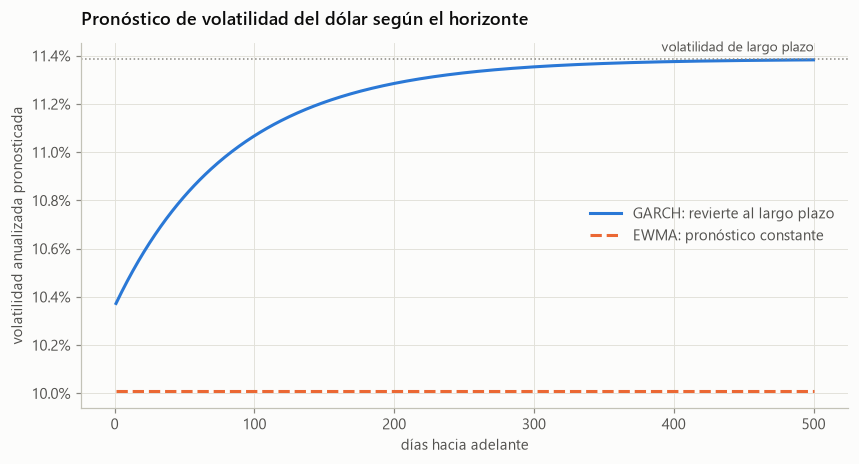

In [8]:
dias = np.arange(1, 501)
garch = [np.sqrt(frm.pronostico_varianza_garch(varianza_hoy, omega, alfa, beta, d) * 252) for d in dias]
ewma_hoy = frm.varianza_ewma(r_dolar.to_numpy())[-1]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(dias, garch, color=COLORES[0], linewidth=2, label="GARCH: revierte al largo plazo")
ax.plot(dias, np.full_like(dias, np.sqrt(ewma_hoy * 252), dtype=float), color=COLORES[1], linewidth=2, linestyle="--",
        label="EWMA: pronóstico constante")
ax.axhline(np.sqrt(vl * 252), color=TINTA_TENUE, linewidth=1, linestyle=":")
ax.annotate("volatilidad de largo plazo", (500, np.sqrt(vl * 252)), xytext=(0, 5), textcoords="offset points", ha="right",
            fontsize=9, color=TINTA_SECUNDARIA)
eje_porcentaje(ax, decimales=1)
ax.set_xlabel("días hacia adelante")
ax.set_ylabel("volatilidad anualizada pronosticada")
ax.set_title("Pronóstico de volatilidad del dólar según el horizonte")
ax.legend(loc="best")
plt.show()

**Lectura.** La persistencia del GARCH es 0,989: un shock de volatilidad tarda unos 61 días hábiles en reducirse a la mitad. La volatilidad actual del dólar, de 10,4% anual, está bajo su nivel de largo plazo de 11,4%, así que el GARCH pronostica que subirá gradualmente. El EWMA, en cambio, pronostica la misma volatilidad para cualquier horizonte.

**Para el examen.**

- Condición de estacionariedad del GARCH(1,1): $\alpha + \beta < 1$. La persistencia $\alpha + \beta$ determina la vida media de los shocks.
- Pronóstico a $n$ días: $E[\sigma^2_{t+n}] = V_L + (\alpha+\beta)^n(\sigma^2_t - V_L)$.
- RiskMetrics usa $\lambda = 0{,}94$ para datos diarios.

## Caso 6. Correlación variable en el tiempo

**Concepto.** La correlación también puede estimarse con EWMA, actualizando la covarianza igual que la varianza:

$$\text{cov}_t = \lambda\,\text{cov}_{t-1} + (1-\lambda)\,x_{t-1}y_{t-1}, \qquad \rho_t = \frac{\text{cov}_t}{\sigma_{x,t}\,\sigma_{y,t}}$$

Se estima la correlación entre el IPSA y el dólar.

**Cuidado con la alineación.** El dólar observado que publica el Banco Central cada día es el promedio de las transacciones del día hábil anterior. Para compararlo con el cierre del IPSA del mismo día hay que usar el dólar observado del día siguiente. Sin ese ajuste, la correlación de toda la muestra sale cercana a cero; con el ajuste, es claramente negativa.

Correlación sin alinear: 0.03. Alineando el dólar observado del día siguiente: -0.26


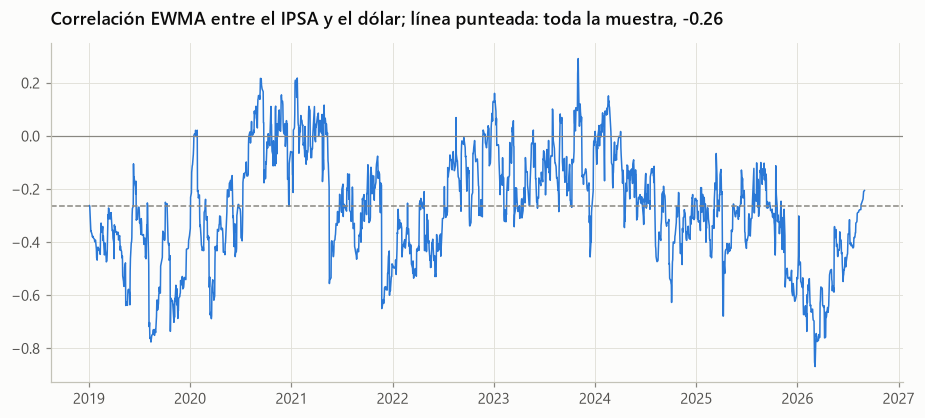

Rango de la correlación EWMA: -0.87 a 0.29


In [9]:
sin_ajuste = pd.concat([log_ipsa, log_dolar], axis=1, join="inner").dropna().corr().iloc[0, 1]
pares = pd.concat([log_ipsa.rename("ipsa"), log_dolar.shift(-1).rename("dolar")], axis=1, join="inner").dropna()
print(f"Correlación sin alinear: {sin_ajuste:.2f}. Alineando el dólar observado del día siguiente: {pares.corr().iloc[0, 1]:.2f}")
lam = 0.94
cov = pares.cov().to_numpy()
var_x, var_y, cov_xy = cov[0, 0], cov[1, 1], cov[0, 1]
correlacion = []
for x, yv in pares.to_numpy():
    correlacion.append(cov_xy / np.sqrt(var_x * var_y))
    var_x, var_y = lam * var_x + (1 - lam) * x**2, lam * var_y + (1 - lam) * yv**2
    cov_xy = lam * cov_xy + (1 - lam) * x * yv
correlacion = pd.Series(correlacion, index=pares.index)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(correlacion.index, correlacion, color=COLORES[0], linewidth=1)
ax.axhline(pares.corr().iloc[0, 1], color=TINTA_TENUE, linestyle="--", linewidth=1)
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_title(f"Correlación EWMA entre el IPSA y el dólar; línea punteada: toda la muestra, {pares.corr().iloc[0, 1]:.2f}")
plt.show()
print(f"Rango de la correlación EWMA: {correlacion.min():.2f} a {correlacion.max():.2f}")

**Lectura.** La correlación entre el IPSA y el dólar es negativa en promedio: cuando la bolsa chilena cae, el peso tiende a depreciarse. Pero cambia mucho en el tiempo: la correlación EWMA va de -0,87 a 0,29, con sus valores más negativos en agosto de 2019 y marzo de 2026. Una sola correlación histórica esconde esa variación, que es clave para medir el riesgo de una cartera con acciones y moneda extranjera.

**Para el examen.**

- La correlación mide solo dependencia lineal. Dos variables pueden ser dependientes con correlación cero.
- Una matriz de correlación válida debe ser semidefinida positiva.
- Las cópulas separan la dependencia de las distribuciones marginales. La cópula gaussiana no tiene dependencia en las colas; la t de Student sí.

## Caso 7. Simulación de Monte Carlo y bootstrap

**Concepto.** Monte Carlo estima un valor esperado promediando simulaciones; su error estándar cae con $1/\sqrt{n}$. Las variables antitéticas, que usan cada número aleatorio $z$ y su opuesto $-z$, reducen la varianza gratis. El bootstrap remuestrea los datos observados para medir la incertidumbre de un estimador sin suponer una distribución.

In [10]:
s0, k, r, sigma, t = 100, 105, 0.05, 0.25, 1
exacto = frm.black_scholes(s0, k, r, sigma, t, "call")
rng = np.random.default_rng(0)
filas = []
for n_sim in [1_000, 10_000, 100_000]:
    z = rng.standard_normal(n_sim)
    precio_final = lambda z: s0 * np.exp((r - sigma**2 / 2) * t + sigma * np.sqrt(t) * z)
    pagos = np.exp(-r * t) * np.maximum(precio_final(z) - k, 0)
    antitetico = np.exp(-r * t) * (np.maximum(precio_final(z) - k, 0) + np.maximum(precio_final(-z) - k, 0)) / 2
    filas.append({"simulaciones": n_sim, "Monte Carlo": pagos.mean(), "error estándar": pagos.std() / np.sqrt(n_sim),
                  "antitético": antitetico.mean(), "error estándar antitético": antitetico.std() / np.sqrt(n_sim)})
print(f"Precio exacto de Black-Scholes: {exacto:.4f}")
pd.DataFrame(filas).set_index("simulaciones")

Precio exacto de Black-Scholes: 10.0022


,Monte Carlo,error estándar,antitético,error estándar antitético
simulaciones,,,,
1000,9.0312,0.4985,9.6766,0.3063
10000,10.1664,0.1694,10.0491,0.0965
100000,9.9784,0.0537,10.0066,0.0308


In [11]:
remuestras = np.array([rg.var_historico(rng.choice(cartera.to_numpy(), len(cartera), replace=True), 0.99)
                       for _ in range(2000)])
print(f"VaR histórico al 99% de la cartera: {rg.var_historico(cartera, 0.99):.2%}")
print(f"Intervalo bootstrap de 90%: {np.percentile(remuestras, 5):.2%} a {np.percentile(remuestras, 95):.2%}")

VaR histórico al 99% de la cartera: 3.54%


Intervalo bootstrap de 90%: 3.03% a 3.74%


**Lectura.**

- **Monte Carlo converge al precio exacto de 10,00.** Con 100.000 simulaciones el error estándar es de 0,05.
- **Las variables antitéticas reducen el error en más de 40%** con el mismo número de simulaciones, lo que equivale a triplicarlas.
- **El VaR histórico también tiene incertidumbre.** El 3,54% de la cartera tiene un intervalo bootstrap de 90% entre 3,0% y 3,7%. Un VaR se reporta como un número, pero es una estimación con error.

**Para el examen.**

- Para reducir a la mitad el error de Monte Carlo hay que cuadruplicar las simulaciones.
- Otras técnicas de reducción de varianza: variables de control y muestreo estratificado.
- El bootstrap supone que las observaciones son independientes; con datos dependientes se usa el bootstrap por bloques.

## Caso 8. Aprendizaje automático: predecir incumplimientos

**Concepto.** La regresión logística modela la probabilidad de un evento binario, como el incumplimiento de un crédito:

$$P(\text{default}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots)}}$$

Se evalúa con la matriz de confusión y la curva ROC. Los datos son simulados: 5.000 deudores con carga financiera, historial de atrasos y antigüedad laboral.

In [12]:
rng = np.random.default_rng(42)
n = 5_000
deudores = pd.DataFrame({"carga_financiera": rng.uniform(0.05, 0.6, n), "atrasos_previos": rng.poisson(0.5, n),
                         "antiguedad_laboral": rng.exponential(5, n)})
logit = -4 + 5 * deudores["carga_financiera"] + 0.8 * deudores["atrasos_previos"] - 0.15 * deudores["antiguedad_laboral"]
deudores["default"] = rng.random(n) < 1 / (1 + np.exp(-logit))
print(f"Tasa de incumplimiento: {deudores['default'].mean():.1%}")

X_ent, X_prueba, y_ent, y_prueba = train_test_split(deudores.drop(columns="default"), deudores["default"],
                                                    test_size=0.3, random_state=0, stratify=deudores["default"])
logistica = LogisticRegression().fit(X_ent, y_ent)
arbol = DecisionTreeClassifier(random_state=0).fit(X_ent, y_ent)   # sin límite de profundidad: se sobreajusta
pd.DataFrame({
    "AUC entrenamiento": [roc_auc_score(y_ent, m.predict_proba(X_ent)[:, 1]) for m in (logistica, arbol)],
    "AUC prueba": [roc_auc_score(y_prueba, m.predict_proba(X_prueba)[:, 1]) for m in (logistica, arbol)],
}, index=["Regresión logística", "Árbol sin límite de profundidad"])

Tasa de incumplimiento: 9.4%


,AUC entrenamiento,AUC prueba
Regresión logística,0.7612,0.7893
Árbol sin límite de profundidad,1.0000,0.5456


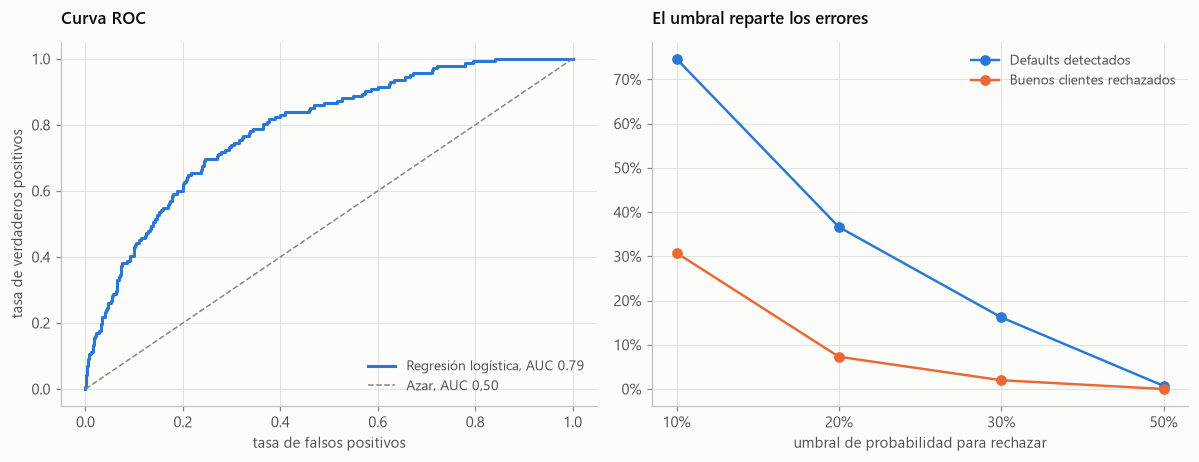

,defaults detectados,buenos rechazados
10%,74.6%,30.8%
20%,36.6%,7.3%
30%,16.2%,2.0%
50%,0.7%,0.0%


In [13]:
probabilidad = logistica.predict_proba(X_prueba)[:, 1]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
fpr, tpr, umbrales = roc_curve(y_prueba, probabilidad)
ax1.plot(fpr, tpr, color=COLORES[0], linewidth=2, label=f"Regresión logística, AUC {roc_auc_score(y_prueba, probabilidad):.2f}")
ax1.plot([0, 1], [0, 1], color=TINTA_TENUE, linestyle="--", linewidth=1, label="Azar, AUC 0,50")
ax1.set_xlabel("tasa de falsos positivos")
ax1.set_ylabel("tasa de verdaderos positivos")
ax1.set_title("Curva ROC", fontsize=11)
ax1.legend(loc="lower right", fontsize=9)

filas = []
for umbral in [0.1, 0.2, 0.3, 0.5]:
    tn, fp, fn, tp = confusion_matrix(y_prueba, probabilidad >= umbral).ravel()
    filas.append({"umbral": umbral, "defaults detectados": tp / (tp + fn), "buenos rechazados": fp / (fp + tn)})
umbrales_tabla = pd.DataFrame(filas).set_index("umbral")
umbrales_tabla.index = [f"{u:.0%}" for u in umbrales_tabla.index]
ax2.plot(range(len(umbrales_tabla)), umbrales_tabla["defaults detectados"], marker="o", color=COLORES[0], label="Defaults detectados")
ax2.plot(range(len(umbrales_tabla)), umbrales_tabla["buenos rechazados"], marker="o", color=COLORES[1], label="Buenos clientes rechazados")
ax2.set_xticks(range(len(umbrales_tabla)), umbrales_tabla.index)
eje_porcentaje(ax2)
ax2.set_xlabel("umbral de probabilidad para rechazar")
ax2.set_title("El umbral reparte los errores", fontsize=11)
ax2.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()
umbrales_tabla.style.format("{:.1%}")

**Lectura.**

- **Sobreajuste evidente.** El árbol sin límite de profundidad tiene un AUC perfecto de 1,00 en entrenamiento, pero de 0,55 en datos nuevos, casi como el azar. La regresión logística, más simple, logra 0,79 en ambos.
- **El umbral es una decisión de negocio.** Rechazar a quien tenga más de 10% de probabilidad de incumplir detecta tres cuartos de los defaults, pero rechaza a casi un tercio de los buenos clientes.

**Para el examen.**

- Sobreajuste: el modelo memoriza el ruido del entrenamiento. Se detecta comparando el desempeño en entrenamiento y en datos no vistos, y se controla con validación cruzada y regularización.
- Ridge penaliza la suma de coeficientes al cuadrado y los achica; LASSO penaliza su valor absoluto y puede dejarlos en cero, seleccionando variables.
- Aprendizaje supervisado, con variable objetivo, frente a no supervisado, como el análisis de componentes principales o k-medias.
- Matriz de confusión: precisión es la fracción de positivos predichos que eran positivos; sensibilidad o recall, la fracción de positivos reales detectados.